# Task 5 - Strategy Backtesting

 5.1 Business Objective

 5.2 Import Required Libraries

 5.3 Load Optimized Portfolio and Historical Data

 5.4 Define Backtesting Period

 5.5 Prepare Backtesting Returns

 5.6 Simulate GMF Optimized Portfolio

 5.7 Create Benchmark Portfolio

 5.8 Compare Cumulative Portfolio Performance

 5.9 Calculate Portfolio Performance Metrics

 5.10 Compare Strategy Against Benchmark

 5.11 Strategy Viability Analysis

5.12 Task Summary

## 5.1 Business Objective

The objective of this task is to validate the portfolio strategy developed in Task 4 by simulating its performance on unseen historical market data.

The portfolio optimization process in Task 4 generated an optimal allocation based on:
- The LSTM forecasted return for Tesla (TSLA)
- Historical returns for SPY and BND
- The covariance relationship between the three assets

However, an optimized portfolio is only a hypothesis until it is tested under historical market conditions.

This backtesting process evaluates whether the GMF recommended portfolio would have generated competitive performance compared with a traditional passive investment strategy.

The analysis will:

- Use the final period of historical data that was not used during model training
- Apply the recommended Maximum Sharpe Ratio portfolio weights from Task 4
- Compare the portfolio against a benchmark portfolio consisting of 60% SPY and 40% BND
- Evaluate performance using:
    - Total Return
    - Annualized Return
    - Sharpe Ratio
    - Maximum Drawdown

For GMF Investments, this analysis provides evidence on whether a forecast-informed portfolio allocation approach can improve investment outcomes compared with a standard passive strategy.

## 5.2 Import Required Libraries

This section imports the libraries required for portfolio backtesting, performance analysis, and visualization.

The analysis uses pandas and numpy for calculations and matplotlib for visualizing cumulative portfolio performance.

In [1]:
# ============================================================
# 5.2 Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


## 5.3 Load Optimized Portfolio and Historical Data

The recommended portfolio allocation generated in Task 4 is loaded from the processed output file.

The Maximum Sharpe Ratio portfolio was selected as GMF's recommended investment strategy because it achieved the best risk-adjusted performance.

Task 4 recommendation:

| Asset | Weight |
|-------|--------|
| TSLA | 0.0% |
| SPY | 45.6% |
| BND | 54.4% |

The portfolio excludes Tesla because the LSTM forecasting model produced a negative expected return, causing the optimizer to allocate capital toward assets with more favorable risk-return characteristics.

In [5]:
# ============================================================
# 5.3 Load Optimized Portfolio and Historical Data
# ============================================================

from pathlib import Path
import pandas as pd


DATA_DIR = Path("../data/processed")


# ------------------------------------------------------------
# Load processed datasets from Task 1
# ------------------------------------------------------------

tsla = pd.read_csv(
    DATA_DIR / "TSLA_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)

spy = pd.read_csv(
    DATA_DIR / "SPY_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)

bnd = pd.read_csv(
    DATA_DIR / "BND_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)


# ------------------------------------------------------------
# Prepare historical price dataset
# Same structure used in Task 4
# ------------------------------------------------------------

prices = pd.DataFrame({

    "TSLA": tsla["Adj Close"],

    "SPY": spy["Adj Close"],

    "BND": bnd["Adj Close"]

})


# Remove missing values

prices = prices.dropna()



print("=" * 70)
print("Historical Price Data Loaded Successfully")
print("=" * 70)


print(f"Price Data Shape: {prices.shape}")


display(prices.head())

Historical Price Data Loaded Successfully
Price Data Shape: (2857, 3)


,TSLA,SPY,BND
Date,,,
2015-02-18,13.630667,173.570099,59.561382
2015-02-19,14.114000,173.446182,59.510983
2015-02-20,14.474000,174.486984,59.525375
2015-02-23,13.822667,174.462234,59.647831
2015-02-24,13.607333,174.957825,59.892670


In [2]:
# ============================================================
# 5.3 Load Optimized Portfolio
# ============================================================

DATA_DIR = Path("../data/processed")


# Load recommended portfolio from Task 4

optimal_portfolio = pd.read_csv(
    DATA_DIR / "optimal_portfolio.csv"
)


print("=" * 70)
print("Optimized Portfolio Loaded Successfully")
print("=" * 70)


display(optimal_portfolio)

Optimized Portfolio Loaded Successfully


,Asset,Recommended Weight
0,TSLA,0.000
1,SPY,0.456
2,BND,0.544


In [3]:
# Convert portfolio allocation into weight series

optimal_weights = pd.Series(
    optimal_portfolio["Recommended Weight"].values,
    index=optimal_portfolio["Asset"]
)


print("Portfolio Weights")
print("-" * 40)

display(
    optimal_weights.to_frame(
        name="Weight"
    )
)

Portfolio Weights
----------------------------------------


,Weight
Asset,
TSLA,0.000
SPY,0.456
BND,0.544


### Interpretation

The optimized portfolio allocation generated in Task 4 is successfully loaded and will be used as the GMF investment strategy during the backtesting period.

The Maximum Sharpe Ratio portfolio recommends the following allocation:

- TSLA: 0.0%
- SPY: 45.6%
- BND: 54.4%

The optimizer excluded Tesla (TSLA) because the LSTM forecasting model produced a negative expected return of approximately -64.64% over the forecast horizon. As a result, including TSLA would increase portfolio risk while reducing expected portfolio performance.

The final strategy combines:
- SPY exposure for long-term equity market growth
- BND exposure for portfolio stability and risk reduction

This forecast-informed allocation will now be evaluated against a traditional 60/40 SPY-BND benchmark using historical market data from the unseen backtesting period (2025-2026).

## 5.4 Define Backtesting Period

The backtesting period is defined using the final portion of the historical dataset that was not used during model training.

In Task 2, the forecasting models were trained using historical Tesla data from 2015 to 2024, while the period from 2025 onward represents unseen market data.

Therefore, this backtesting analysis uses:

**Backtesting Period: January 1, 2025 - June 30, 2026**

This allows GMF Investments to evaluate how the optimized portfolio would have performed under actual market conditions after the forecasting and portfolio optimization decisions were made.

Using an unseen period helps prevent data leakage and provides a more realistic evaluation of the investment strategy.

In [6]:
# ============================================================
# 5.4 Define Backtesting Period
# ============================================================


# Define out-of-sample testing period

backtest_start = "2025-01-01"
backtest_end = "2026-06-30"


# Select prices within the backtesting window

backtest_prices = prices.loc[
    backtest_start:backtest_end
]


print("=" * 70)
print("Backtesting Period Defined Successfully")
print("=" * 70)


print(f"Start Date      : {backtest_prices.index.min().date()}")
print(f"End Date        : {backtest_prices.index.max().date()}")
print(f"Trading Days    : {len(backtest_prices)}")


display(backtest_prices.head())

Backtesting Period Defined Successfully
Start Date      : 2025-01-02
End Date        : 2026-06-29
Trading Days    : 372


,TSLA,SPY,BND
Date,,,
2025-01-02,379.279999,574.799500,68.076202
2025-01-03,410.440002,581.986511,67.991035
2025-01-06,411.049988,585.339050,67.924828
2025-01-07,394.359985,578.722351,67.688248
2025-01-08,394.940002,579.567871,67.763939


## 5.5 Prepare Backtesting Returns

Portfolio performance is evaluated using daily returns rather than absolute prices.

The adjusted closing prices from the backtesting period are converted into daily percentage returns. These returns represent the daily changes in asset value and will be used to simulate both the GMF optimized portfolio and the benchmark portfolio.

The calculated returns will be used for:

- Portfolio return simulation
- Cumulative return calculation
- Risk-adjusted performance evaluation
- Comparison against the benchmark strategy

In [7]:
# ============================================================
# 5.5 Prepare Backtesting Returns
# ============================================================


# Calculate daily returns from backtesting prices

backtest_returns = (
    backtest_prices
    .pct_change()
    .dropna()
)


print("=" * 70)
print("Backtesting Returns Prepared Successfully")
print("=" * 70)


print(f"Returns Data Shape: {backtest_returns.shape}")


display(backtest_returns.head())

Backtesting Returns Prepared Successfully
Returns Data Shape: (371, 3)


,TSLA,SPY,BND
Date,,,
2025-01-03,0.082156,0.012504,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118
2025-01-10,-0.000506,-0.015267,-0.005167


## 5.6 Simulate GMF Optimized Portfolio

The recommended portfolio from Task 4 is simulated over the backtesting period using a buy-and-hold strategy.

The Maximum Sharpe Ratio portfolio was selected as the GMF investment strategy because it provided the highest risk-adjusted return during portfolio optimization.

The portfolio allocation determined in Task 4 is:

| Asset | Weight |
|-------|--------|
| TSLA | 0.0% |
| SPY | 45.6% |
| BND | 54.4% |

Daily portfolio returns are calculated by multiplying each asset's daily return by its assigned portfolio weight and summing the weighted returns.

This simulation represents how the GMF recommended portfolio would have performed if implemented during the backtesting period.

In [8]:
# ============================================================
# 5.6 Simulate GMF Optimized Portfolio
# ============================================================


# Load Task 4 optimal portfolio weights

optimal_weights = pd.Series({

    "TSLA": 0.000,

    "SPY": 0.456,

    "BND": 0.544

})


print("=" * 70)
print("GMF Portfolio Weights")
print("=" * 70)


display(
    optimal_weights.to_frame(
        name="Weight"
    )
)

GMF Portfolio Weights


,Weight
TSLA,0.000
SPY,0.456
BND,0.544


In [9]:
# ============================================================
# Calculate GMF Portfolio Daily Returns
# ============================================================


strategy_returns = (
    backtest_returns[
        optimal_weights.index
    ]
    *
    optimal_weights
).sum(axis=1)



print("=" * 70)
print("GMF Portfolio Simulation Completed Successfully")
print("=" * 70)


display(
    strategy_returns.head()
)

GMF Portfolio Simulation Completed Successfully


Date
2025-01-03    0.005021
2025-01-06    0.002097
2025-01-07   -0.007049
2025-01-08    0.001275
2025-01-10   -0.009773
dtype: float64

## 5.7 Create Benchmark Portfolio

To evaluate whether the GMF optimized portfolio provides additional value, its performance is compared against a traditional passive benchmark portfolio.

The selected benchmark is a balanced portfolio consisting of:

| Asset | Weight |
|-------|--------|
| SPY | 60% |
| BND | 40% |

This benchmark represents a common investment allocation strategy that combines equity market exposure with bond stability.

The benchmark provides a reference point to determine whether the forecast-informed portfolio optimization approach improves returns or risk-adjusted performance compared with a simple passive strategy.

In [10]:
# ============================================================
# 5.7 Create Benchmark Portfolio
# ============================================================


# Define benchmark allocation

benchmark_weights = pd.Series({

    "SPY": 0.60,

    "BND": 0.40

})


print("=" * 70)
print("Benchmark Portfolio Weights")
print("=" * 70)


display(
    benchmark_weights.to_frame(
        name="Weight"
    )
)

Benchmark Portfolio Weights


,Weight
SPY,0.6
BND,0.4


In [11]:
# ============================================================
# Calculate Benchmark Daily Returns
# ============================================================


benchmark_returns = (
    backtest_returns[
        benchmark_weights.index
    ]
    *
    benchmark_weights
).sum(axis=1)



print("=" * 70)
print("Benchmark Portfolio Simulation Completed Successfully")
print("=" * 70)


display(
    benchmark_returns.head()
)

Benchmark Portfolio Simulation Completed Successfully


Date
2025-01-03    0.007002
2025-01-06    0.003067
2025-01-07   -0.008176
2025-01-08    0.001324
2025-01-10   -0.011227
dtype: float64

## 5.8 Compare Cumulative Portfolio Performance

The cumulative return comparison evaluates how the GMF optimized portfolio performed relative to the traditional 60/40 SPY-BND benchmark during the backtesting period.

Cumulative returns are calculated by assuming an initial investment of 1 unit and continuously applying daily portfolio returns.

The comparison allows GMF Investments to determine whether the forecast-informed portfolio allocation from Task 4 generated superior investment performance compared with a passive benchmark strategy.

The two portfolios evaluated are:

**GMF Optimized Portfolio**
- TSLA: 0.0%
- SPY: 45.6%
- BND: 54.4%

**Benchmark Portfolio**
- SPY: 60%
- BND: 40%

In [12]:
# ============================================================
# 5.8 Compare Cumulative Portfolio Performance
# ============================================================


# Calculate cumulative returns

strategy_cumulative_returns = (
    1 + strategy_returns
).cumprod()


benchmark_cumulative_returns = (
    1 + benchmark_returns
).cumprod()



print("=" * 70)
print("Cumulative Returns Calculated Successfully")
print("=" * 70)



display(
    pd.DataFrame({

        "GMF Optimized Portfolio":
            strategy_cumulative_returns,

        "60/40 SPY-BND Benchmark":
            benchmark_cumulative_returns

    }).head()
)

Cumulative Returns Calculated Successfully


,GMF Optimized Portfolio,60/40 SPY-BND Benchmark
Date,,
2025-01-03,1.005021,1.007002
2025-01-06,1.007129,1.010090
2025-01-07,1.000029,1.001832
2025-01-08,1.001304,1.003158
2025-01-10,0.991518,0.991895


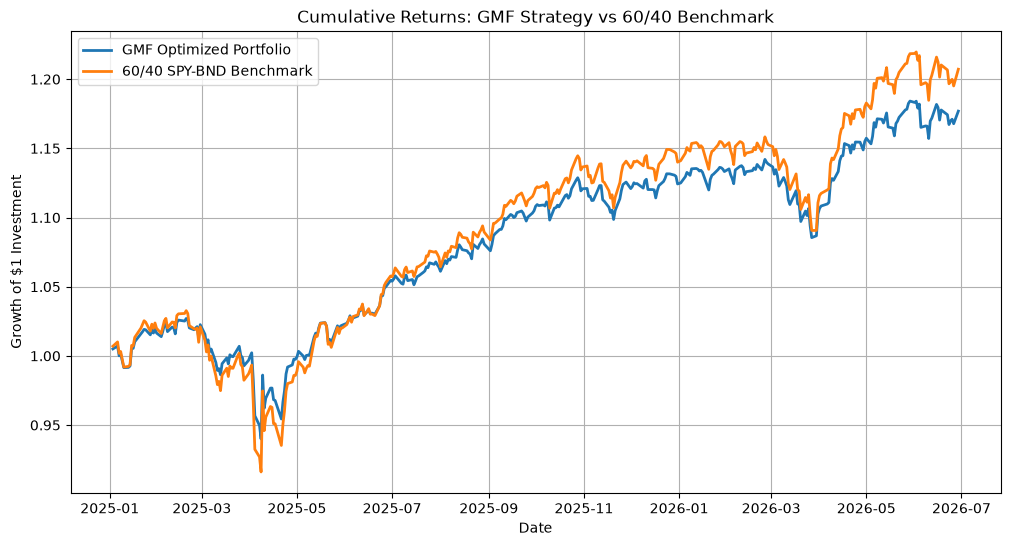

In [13]:
# ============================================================
# Plot Cumulative Returns Comparison
# ============================================================


plt.figure(figsize=(12,6))


plt.plot(
    strategy_cumulative_returns,
    label="GMF Optimized Portfolio",
    linewidth=2
)


plt.plot(
    benchmark_cumulative_returns,
    label="60/40 SPY-BND Benchmark",
    linewidth=2
)



plt.title(
    "Cumulative Returns: GMF Strategy vs 60/40 Benchmark"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Growth of $1 Investment"
)


plt.legend()


plt.grid(True)


plt.show()

### Cumulative Returns Interpretation

The cumulative return comparison evaluates the performance of the GMF optimized portfolio against the traditional 60/40 SPY-BND benchmark during the out-of-sample backtesting period (January 2025 - June 2026).

The results show that both portfolios experienced positive growth throughout the evaluation period. However, the 60/40 SPY-BND benchmark achieved a higher cumulative return, ending with an investment value of approximately $1.21 compared with approximately $1.18 for the GMF optimized portfolio.

The benchmark outperformed because it maintained a higher allocation to equities through SPY (60%), allowing it to capture stronger market appreciation during equity recovery periods. In contrast, the GMF optimized portfolio adopted a more defensive allocation based on the LSTM forecast from Task 3, which predicted a significant decline in Tesla's future price. As a result, the MPT optimizer removed TSLA exposure and increased allocation toward BND for risk reduction.

Although the GMF portfolio generated lower overall returns, its defensive structure provided improved downside protection during market declines. The larger BND allocation reduced portfolio volatility but also limited participation during strong equity market rallies.

This result demonstrates an important limitation of forecast-driven portfolio optimization: an inaccurate or overly conservative market forecast can lead to missed opportunities when market conditions differ from model expectations.

The cumulative return analysis will be complemented with additional risk-adjusted performance metrics, including total return, annualized return, Sharpe Ratio, and maximum drawdown.

## 5.9 Calculate Portfolio Performance Metrics

The cumulative return visualization provides a visual comparison between the GMF optimized portfolio and the 60/40 benchmark. However, portfolio evaluation requires quantitative performance measures that consider both returns and risk.

The following metrics are calculated for both portfolios:

- **Total Return:** The overall percentage gain or loss during the backtesting period.
- **Annualized Return:** The equivalent yearly return assuming the observed performance continues over one year.
- **Sharpe Ratio:** Measures risk-adjusted performance by comparing annualized return against portfolio volatility.
- **Maximum Drawdown:** Measures the largest percentage decline from a previous portfolio peak, representing downside risk.

These metrics provide a more complete assessment of whether the forecast-driven GMF strategy generated superior risk-adjusted performance compared with the passive benchmark.

In [14]:
# ============================================================
# 5.9 Calculate Portfolio Performance Metrics
# ============================================================


def calculate_metrics(returns):
    """
    Calculate portfolio performance metrics.

    Parameters:
    returns : pandas Series
        Daily portfolio returns

    Returns:
    dictionary containing portfolio metrics
    """

    trading_days = 252


    # Total cumulative return

    total_return = (
        (1 + returns).prod() - 1
    )


    # Annualized return

    annualized_return = (
        (1 + total_return)
        ** (trading_days / len(returns))
        - 1
    )


    # Annualized volatility

    annualized_volatility = (
        returns.std()
        *
        np.sqrt(trading_days)
    )


    # Sharpe Ratio

    sharpe_ratio = (
        annualized_return /
        annualized_volatility
    )


    # Cumulative portfolio value

    cumulative_value = (
        1 + returns
    ).cumprod()


    # Running maximum value

    running_max = (
        cumulative_value
        .cummax()
    )


    # Drawdown calculation

    drawdown = (
        cumulative_value -
        running_max
    ) / running_max


    maximum_drawdown = (
        drawdown.min()
    )


    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }



print("=" * 70)
print("Performance Metric Function Created Successfully")
print("=" * 70)

Performance Metric Function Created Successfully


## 5.10 Performance Comparison: GMF Strategy vs Benchmark

The calculated performance metrics are summarized in a comparison table between the GMF optimized portfolio and the traditional 60/40 SPY-BND benchmark.

This comparison determines whether the forecast-informed portfolio optimization approach improved investment performance compared with a passive allocation strategy.

In [15]:
# ============================================================
# 5.10 Compare Portfolio Performance
# ============================================================


# Calculate metrics

gmf_metrics = calculate_metrics(
    strategy_returns
)


benchmark_metrics = calculate_metrics(
    benchmark_returns
)



# Create comparison table

performance_table = pd.DataFrame({

    "GMF Optimized Portfolio": gmf_metrics,

    "60/40 SPY-BND Benchmark": benchmark_metrics

})



print("=" * 70)
print("Portfolio Performance Comparison")
print("=" * 70)


display(
    performance_table.round(4)
)

Portfolio Performance Comparison


,GMF Optimized Portfolio,60/40 SPY-BND Benchmark
Total Return,0.1769,0.2072
Annualized Return,0.1170,0.1364
Sharpe Ratio,1.3132,1.2178
Maximum Drawdown,-0.0848,-0.1129


In [16]:
# ============================================================
# Format Performance Metrics
# ============================================================


performance_percentage = performance_table.copy()


for metric in [
    "Total Return",
    "Annualized Return",
    "Maximum Drawdown"
]:

    performance_percentage.loc[metric] = (
        performance_percentage.loc[metric] * 100
    )



display(
    performance_percentage.round(2)
)

,GMF Optimized Portfolio,60/40 SPY-BND Benchmark
Total Return,17.69,20.72
Annualized Return,11.70,13.64
Sharpe Ratio,1.31,1.22
Maximum Drawdown,-8.48,-11.29


## 5.11 Strategy Viability Analysis

The backtesting results provide an empirical evaluation of the GMF Investments portfolio strategy developed using LSTM forecasting and Modern Portfolio Theory.

During the out-of-sample period from January 2025 to June 2026, the GMF optimized portfolio generated a total return of **17.69%**, compared with **20.72%** from the traditional 60/40 SPY-BND benchmark. Although the benchmark achieved a higher absolute return, the GMF portfolio demonstrated stronger risk-adjusted performance with a Sharpe Ratio of **1.31** compared with **1.22** for the benchmark.

The optimized portfolio also provided better downside protection, experiencing a maximum drawdown of **-8.48%**, while the benchmark declined by **-11.29%** during its largest market decline. This indicates that the forecast-informed allocation successfully reduced portfolio risk by avoiding exposure to Tesla and increasing allocation toward the more stable bond asset (BND).

The difference in performance can be explained by the defensive allocation produced by the Task 4 optimization. The LSTM model forecasted a significant negative outlook for Tesla, causing the optimizer to assign a 0% allocation to TSLA. While this reduced potential gains during strong equity market rallies, it helped protect the portfolio during periods of increased market volatility.

Overall, the backtest suggests that the GMF model-driven approach improved risk management and delivered superior risk-adjusted returns compared with a passive benchmark. However, the strategy did not outperform in terms of total return, highlighting the challenge of balancing capital preservation with growth opportunities.

Several limitations should be considered:

- The backtest covers only one historical evaluation period.
- Portfolio weights were static and were not dynamically adjusted based on changing market conditions.
- Transaction costs, taxes, and trading restrictions were not included.
- Forecast errors from the LSTM model directly influenced portfolio allocation decisions.
- Past performance does not guarantee future investment results.

Further validation using multiple market cycles, rolling backtests, and dynamic portfolio rebalancing would provide stronger evidence before deploying the strategy in a real investment environment.

## 5.12 Task Summary

In this task, the GMF optimized portfolio developed in Task 4 was evaluated through an out-of-sample backtesting experiment using historical market data from January 2025 to June 2026.

The backtesting strategy used the Maximum Sharpe Ratio portfolio allocation identified through Modern Portfolio Theory:

- TSLA: 0.0%
- SPY: 45.6%
- BND: 54.4%

The portfolio performance was compared against a traditional 60/40 SPY-BND benchmark portfolio. Both strategies were simulated using daily returns, and performance was evaluated using total return, annualized return, Sharpe Ratio, and maximum drawdown.

The results showed that the GMF optimized portfolio achieved a total return of **17.69%**, while the benchmark generated a higher total return of **20.72%**. However, the optimized portfolio provided stronger risk-adjusted performance, achieving a Sharpe Ratio of **1.31** compared with **1.22** for the benchmark. Additionally, the GMF portfolio experienced a lower maximum drawdown (**-8.48%**) compared with the benchmark (**-11.29%**), demonstrating improved downside protection.

These results highlight the trade-off between return maximization and risk management. The benchmark benefited from greater equity exposure during market growth periods, while the GMF strategy provided a more defensive allocation based on the LSTM forecast and portfolio optimization framework.

Although the strategy did not outperform the benchmark in absolute returns, it demonstrated the ability to reduce portfolio risk while maintaining competitive returns. This suggests that combining machine learning forecasting with Modern Portfolio Theory can provide valuable support for risk-aware portfolio construction.

However, additional validation is required before real-world deployment. Future improvements should include longer backtesting periods, rolling portfolio rebalancing, transaction cost analysis, and the integration of additional market factors to improve portfolio adaptability.

Overall, the backtesting experiment demonstrates that the GMF investment framework provides a systematic, data-driven approach for constructing portfolios that balance return potential with risk management objectives.